# Parameter estimation results — PWL membrane water balance

Reproduces the plots of `plot_resuts.ipynb` using the piecewise-linear
membrane water balance model (`MembraneWaterBalanceModelPiecewise`) and the
corresponding cross-validation results file
`results_Affonso_Nobrega_et_al_2026_JES_pwl_membrane.csv`.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import marapendi as mrpd
from marapendi.estimation.estimation import SteadyStateModel
from marapendi.estimation.cross_validation import (
    run_cross_validation,
    save_cross_validation_results,
    load_cross_validation_results,
    plot_rmse_vs_complexity,
    plot_cross_validation_curves,
    plot_parameter_vs_complexity,
    get_complexity_levels,
    get_folds_for_complexity,
    rmse_complexity_table,
)

plt.rcParams.update({"text.usetex": False})

In [2]:
filename = 'test'

In [3]:
_exp_data_csv = """case,current-density,voltage,hfr
1,0,0.911451,
1,0.08,0.819964,0.0413076
1,0.2,0.783851,
1,0.4,0.746728,0.0397381
1,0.6,0.7192,
1,0.8,0.691927,
1,1,0.666024,0.0369162
1,1.2,0.637758,
1,1.4,0.609555,
1,1.56,0.587704,
2,0,0.946503,
2,0.08,0.861721,0.0386086
2,0.2,0.823163,
2,0.4,0.782723,0.0377255
2,0.6,0.750069,
2,0.8,0.719233,
2,1,0.687873,0.0364815
2,1.2,0.656312,
2,1.4,0.626726,
2,1.56,0.605712,
2,1.59,0.599881,
3,0,0.919656,
3,0.08,0.814908,0.04987
3,0.2,0.772305,
3,0.4,0.730443,0.0554072
3,0.6,0.69555,
3,0.8,0.664588,
3,1,0.636433,0.0528002
3,1.2,0.610458,
3,1.4,0.583257,
3,1.56,0.549974,
3,1.8,0.494066,
3,1.96,0.436816,
4,0,0.929941,
4,0.08,0.851711,0.0368974
4,0.2,0.816085,
4,0.4,0.785446,0.0374853
4,0.6,0.760909,
4,0.8,0.740034,
4,1,0.720167,0.0365731
4,1.2,0.701043,
4,1.4,0.679064,
4,1.56,0.657917,
4,1.8,0.619024,
4,2,0.578545,
5,0,0.927345,
5,0.08,0.843686,0.0363732
5,0.2,0.807182,
5,0.4,0.774042,0.037437
5,0.6,0.75205,
5,0.8,0.729708,
5,1,0.707576,0.0338028
5,1.2,0.684814,
5,1.4,0.661233,
5,1.56,0.642694,
5,1.79,0.599711,
6,0,0.922887,
6,0.08,0.810585,0.0478001
6,0.2,0.774263,
6,0.4,0.737869,0.0453726
6,0.6,0.70696,
6,0.8,0.678401,
6,1,0.651822,0.0446186
6,1.2,0.626913,
6,1.4,0.596979,
6,1.56,0.566364,
7,0,0.929048,
7,0.08,0.829254,0.0376741
7,0.2,0.790205,
7,0.4,0.752194,0.0370008
7,0.6,0.722174,
7,0.8,0.693328,
7,1,0.664069,0.0362274
7,1.2,0.635142,
7,1.4,0.606177,
7,1.56,0.583332,
8,0,0.919067,
8,0.08,0.826517,0.0333321
8,0.2,0.791053,
8,0.4,0.757887,0.0318667
8,0.6,0.733209,
8,0.8,0.711132,
8,1,0.689397,0.0322763
8,1.16,0.672052,
8,1.4,0.640206,
8,1.56,0.611004,
8,1.6,0.600006,
9,0,0.91687,
9,0.08,0.823573,0.0330154
9,0.2,0.782671,
9,0.4,0.748927,0.032455
9,0.6,0.722018,
9,0.8,0.695022,
9,1,0.66496,0.0322796
9,1.2,0.631988,
9,1.4,0.596083,
9,1.56,0.565461,
"""

_exp_data_df = pd.read_csv(pd.io.common.StringIO(_exp_data_csv))
_exp_data_df['current-density'] *= 1e4
_exp_data_df['hfr'] *= 1e-4

In [4]:
_exp_data_df['case']

0     1
1     1
2     1
3     1
4     1
     ..
92    9
93    9
94    9
95    9
96    9
Name: case, Length: 97, dtype: int64

## Experimental data

## Fuel-cell model with piecewise-linear membrane water balance

In [5]:
def create_cell(params):
    membrane = mrpd.PFSA(
        ionomer=mrpd.PFSAIonomer(
            equivalent_weight=params['memb-equiv-weight'],
            dry_density=2000.,
            conductivity_exp=params['memb-cond-exp'],
            conductivity_activation_energy=params['memb-E-act-cond'],
            conductivity_correction=params['memb-cond-correction'],
            reference_water_diffusivity=params['memb-water-diff'],
            reference_water_absorption_coefficient=params['memb-abs-constant'],
            water_diffusivity_activation_energy=params['E-act-memb-diff'],
            water_absorption_activation_energy=params['E-act-memb-abs'],
        ),
        dry_thickness=params['memb-thickness'],
    )

    orr_kinetics = mrpd.ElectrochemicalReaction(
        reference_exchange_current_density=params['i0-c'],
        reaction_order=params['gamma-c'],
        activation_energy=params['E-act-ca'],
        reference_activity=1.01325e5,
        reference_temperature=353.15,
        number_of_electrons=1,
        charge_transfer_coeff=params['alpha-c'],
    )

    liq_model = mrpd.DarcyTransportModel(J_function_exponent=params['wet-transition'])

    gdl = {
        side: mrpd.GasDiffusionLayer(
            thickness=params['gdl-thickness'],
            contact_angle=params['gdl-theta'],
            effective_gas_diffusion_ratio=params['gdl-eff-diff-ratio'],
            absolute_permeability=params['gdl-abs-perm'],
            porosity=params['gdl-porosity'],
            thermal_conductivity=params['gdl-thermal-cond'],
            two_phase_transport_model=liq_model,
            transport_resistance_model=mrpd.PorousGasDiffusionModel(
                water_saturation_exponent=params['n_s']),
        ) for side in ['ca', 'an']
    }

    ch = {
        side: mrpd.FlowChannel(
            height=params['ch-height'], width=1e-3, n_parallel=1, length=21 * 50e-3,
            reactant='o2' if side == 'ca' else 'h2',
            transport_resistance_model=mrpd.ChannelGasResistanceModel(
                sherwood=params['Sh'], B_ch=params['B_ch']),
        ) for side in ['an', 'ca']
    }

    ionomer = mrpd.PFSAIonomer(
        conductivity_correction=params['ionomer-cond-corr'],
        conductivity_exp=params['ionomer-cond-exp'],
        conductivity_activation_energy=params['ionomer-E-act-cond'],
    )

    ca_cl = mrpd.PtCCatalystLayer(
        ecsa=params['ecsa'], platinum_loading=params['pt-loading'], ionomer=ionomer,
        catalyst_platinum_weight_percent=params['pt-wt-percent'],
        ionomer_to_carbon_ratio=params['ic-ratio'],
        ionomer_k1=params['ionomer-k1'], ionomer_k2=params['ionomer-k2'],
        ionomer_k3=params['ionomer-k3'],
        pore_diameter=params['cl-pore-diameter'], omega_PtO=0,
        carbon_agglomerate_radius=params['radius-carbon'],
        thickness=params['pt-loading'] * 2.8e-6 / 0.1e-2,
        absolute_permeability=params['cl-abs-perm'], contact_angle=params['cl-theta'],
        thermal_conductivity=params['cl-thermal-cond'], reaction=orr_kinetics,
        two_phase_transport_model=liq_model,
        transport_resistance_model=mrpd.PorousGasDiffusionModel(water_saturation_exponent=1.5),
    )

    an_cl = mrpd.PtCCatalystLayer(
        ecsa=params['ecsa'], platinum_loading=1e-3,
        catalyst_platinum_weight_percent=params['pt-wt-percent'],
        ionomer_to_carbon_ratio=params['ic-ratio'], ionomer=ionomer,
        pore_diameter=params['cl-pore-diameter'],
        carbon_agglomerate_radius=params['radius-carbon'],
        thickness=2.8e-6, absolute_permeability=params['cl-abs-perm'],
        contact_angle=params['cl-theta'],
        thermal_conductivity=params['cl-thermal-cond'],
        two_phase_transport_model=liq_model,
        transport_resistance_model=mrpd.PorousGasDiffusionModel(water_saturation_exponent=1.5),
    )

    return mrpd.FuelCell(
        electrical_resistance=params['elec-resistance'],
        area=25e-4,
        ca=mrpd.FuelCellSide(
            cl=ca_cl, gdl=gdl['ca'], has_gdl=True, has_mpl=False, ch=ch['ca'],
            thermal_contact_resistance=params['tcr'],
        ),
        an=mrpd.FuelCellSide(
            cl=an_cl, gdl=gdl['an'], has_gdl=True, has_mpl=False, ch=ch['an'],
            thermal_contact_resistance=params['tcr'],
        ),
        membrane=membrane,
    )

In [6]:
conditions_df = pd.DataFrame({
    'case':        [1,2,3,4,5,6,7,8,9],
    'cell-temperature': np.array([80, 50, 80, 80, 80, 90, 50, 80, 80]) + 273.15,
    'pressure-an': np.array([1.5, 2.5, 1.5, 2.5, 2.5, 1.5, 1.5, 1.5, 1.5]) * 1e5,
    'pressure-ca': np.array([1.5, 2.5, 1.5, 2.5, 2.3, 1.5, 1.5, 1.5, 1.5]) * 1e5,
    'rh-an':       np.array([50, 50, 30, 30, 50, 50, 80, 80, 80]) / 100,
    'rh-ca':       np.array([50, 50, 30, 30, 30, 50, 80, 80, 80]) / 100,
    'st-an':       [1.5, 1.5, 1.2, 2.0, 1.5, 1.5, 1.5, 2.0, 1.5],
    'st-ca':       [2.0, 2.0, 2.5, 2.5, 2.0, 2.5, 2.0, 2.5, 1.5],
})

In [7]:
from marapendi.estimation.polarization_curve_calibration import Parameter, UnknownParameter

unknown_parameters = [
    # ORR kinetics - 4 params
    UnknownParameter(value=2.54e-4, key='i0-c',     symbol=r'$i_{0,ca}$',                         units='A/cm² Pt',    factor=1,    initial_guess=2.54e-4, lower_bound=1e-5,   upper_bound=1e-2,   is_linear=False),
    UnknownParameter(value=0.54,    key='gamma-c',  symbol=r'$\gamma_{ca}$',                       units='n.d.',        factor=1,    initial_guess=0.54,    lower_bound=0.5,    upper_bound=1.),
    UnknownParameter(value=1.,      key='alpha-c',  symbol=r'$\alpha_{ca}$',                       units='n.d.',        factor=1,    initial_guess=1.,      lower_bound=0.5,    upper_bound=1.),
    UnknownParameter(value=67e6,    key='E-act-ca', symbol='$E_{act,ca}$',                         units='kJ/mol',      factor=1e6,  initial_guess=67e6,    lower_bound=30e6,   upper_bound=80e6),

    # CL properties - 7 params
    UnknownParameter(value=.3e-2,   key='pt-loading',       symbol=r'$L_{\text{Pt},ca}$',          units='mg/cm²',      factor=1e-2, initial_guess=.3e-2,   lower_bound=0.2e-2, upper_bound=0.5e-2),
    UnknownParameter(value=60e3,    key='ecsa',             symbol='ECSA',                         units='m²/g',        factor=1e3,  initial_guess=60e3,    lower_bound=40e3,   upper_bound=90e3),
    UnknownParameter(value=1.4,     key='ic-ratio',         symbol='IC$_{ca}$',                    units='n.d.',        factor=1,    initial_guess=1.4,     lower_bound=0.5,    upper_bound=1.5),
    UnknownParameter(value=25e-9,   key='radius-carbon',    symbol='$r_C$',                        units='nm',          factor=1e-9, initial_guess=25e-9,   lower_bound=10e-9,  upper_bound=40e-9),
    UnknownParameter(value=1e-13,   key='cl-abs-perm',      symbol=r'$K^{abs}_{\text{CL}}$',       units='e-12 m²',     factor=1e-12,initial_guess=1e-13,   lower_bound=1e-14,  upper_bound=1e-12,  is_linear=False),
    UnknownParameter(value=40e-9,   key='cl-pore-diameter', symbol=r'$d_{p,\text{CL}}$',           units='nm',          factor=1e-9, initial_guess=40e-9,   lower_bound=10e-9,  upper_bound=70e-9),
    UnknownParameter(value=97.,     key='cl-theta',         symbol=r'$\theta_{\text{CL}}$',        units='deg',         factor=1,    initial_guess=97.,     lower_bound=92,     upper_bound=110),

    # Ionomer properties
    UnknownParameter(value=8.5,     key='ionomer-k1',        symbol='$k_1$',                       units='n.d.',        factor=1,    initial_guess=8.5,     lower_bound=2,      upper_bound=10),
    UnknownParameter(value=5.4,     key='ionomer-k2',        symbol='$k_2$',                       units='n.d.',        factor=1,    initial_guess=5.4,     lower_bound=2,      upper_bound=10),
    UnknownParameter(value=5.4,     key='ionomer-k3',        symbol='$k_3$',                       units='n.d.',        factor=1,    initial_guess=5.4,     lower_bound=2,      upper_bound=10),
    UnknownParameter(value=1,       key='ionomer-cond-corr', symbol=r'$\xi_{\sigma}^{ion}$',       units='n.d.',        factor=1,    initial_guess=1,       lower_bound=0.1,    upper_bound=50,     is_linear=False),
    # UnknownParameter(value=1.5,   key='ionomer-cond-exp',  symbol=r'$n_{\sigma}^{ion}$',         units='n.d.',        factor=1,    initial_guess=1.5,     lower_bound=1,      upper_bound=2),
    # UnknownParameter(value=15e6,  key='ionomer-E-act-cond',symbol=r'$E^{ion}_{act,\sigma}$',     units='kJ/mol',      factor=1e6,  initial_guess=15e6,    lower_bound=5e6,    upper_bound=30e6),

    # Membrane properties
    UnknownParameter(value=1.,      key='ix-corr',           symbol=r'$\xi_x$',                    units='n.d.',        factor=1,    initial_guess=1.,      lower_bound=0.5,    upper_bound=5),
    # UnknownParameter(value=1.0,   key='memb-cond-correction',symbol=r'$\xi_{\sigma}^{mb}$',      units='n.d.',        factor=1,    initial_guess=1.0,     lower_bound=0.1,    upper_bound=50,     is_linear=False),
    # UnknownParameter(value=1.5,   key='memb-cond-exp',     symbol=r'$n_{\sigma}^{mb}$',          units='n.d.',        factor=1,    initial_guess=1.5,     lower_bound=1,      upper_bound=2),
    # UnknownParameter(value=15e6,  key='memb-E-act-cond',   symbol=r'$E^{mb}_{act,\sigma}$',      units='kJ/mol',      factor=1e6,  initial_guess=15e6,    lower_bound=5e6,    upper_bound=30e6),
    UnknownParameter(value=12e-6,   key='memb-thickness',    symbol=r'$\delta_{mb}$',               units='μm',          factor=1e-6, initial_guess=12e-6,   lower_bound=8e-6,   upper_bound=15e-6),
    UnknownParameter(value=1100.,   key='memb-equiv-weight', symbol='EW',                           units='g/mol',       factor=1,    initial_guess=1100.,   lower_bound=700.,   upper_bound=1100.),
    UnknownParameter(value=2e-10,   key='memb-water-diff',   symbol=r'$D_{\lambda}$',               units='1e-10 m²/s',  factor=1e-10,initial_guess=2e-10,   lower_bound=1e-10,  upper_bound=10e-10),
    UnknownParameter(value=1e-5,    key='memb-abs-constant', symbol='$k_{abs}$',                    units='m/s',         factor=1,    initial_guess=1e-5,    lower_bound=1e-6,   upper_bound=1e-4,   is_linear=False),
    # UnknownParameter(value=20e6,  key='E-act-memb-diff',   symbol=r'$E^{mb}_{act,D_\lambda}$',   units='kJ/mol',      factor=1e6,  initial_guess=20e6,    lower_bound=15e6,   upper_bound=30e6),
    # UnknownParameter(value=20e6,  key='E-act-memb-abs',    symbol=r'$E^{mb}_{act,abs}$',          units='kJ/mol',      factor=1e6,  initial_guess=20e6,    lower_bound=15e6,   upper_bound=30e6),

    # GDL properties - 5 params
    UnknownParameter(value=150e-6,  key='gdl-thickness',     symbol=r'$\delta_{\text{GDL}}$',       units='μm',          factor=1e-6, initial_guess=150e-6,  lower_bound=100e-6, upper_bound=250e-6),
    UnknownParameter(value=0.3,     key='gdl-eff-diff-ratio',symbol=r'$D_{\text{GDL}}^{\mathit{eff}}/D$', units='n.d.', factor=1,    initial_guess=0.3,     lower_bound=0.05,   upper_bound=0.5),
    UnknownParameter(value=1e-12,   key='gdl-abs-perm',      symbol=r'$K^{abs}_{\text{GDL}}$',      units='e-12 m²',     factor=1e-12,initial_guess=1e-12,   lower_bound=1e-13,  upper_bound=1e-11,  is_linear=False),
    UnknownParameter(value=0.5,     key='gdl-thermal-cond',  symbol=r'$k_{\text{GDL}}$',            units='W/mK',        factor=1,    initial_guess=0.5,     lower_bound=0.05,   upper_bound=2,      is_linear=False),
    UnknownParameter(value=120.,    key='gdl-theta',         symbol=r'$\theta_{\text{GDL}}$',        units='deg',         factor=1,    initial_guess=120.,    lower_bound=100,    upper_bound=150),

    # Other - 6 params
    UnknownParameter(value=4.4e-4,  key='tcr',               symbol='TCR',                          units='1e-4 Kcm²/W', factor=1e-4, initial_guess=4.4e-4,  lower_bound=0,      upper_bound=10e-4),
    UnknownParameter(value=33e-7,   key='elec-resistance',   symbol='$r_{elec}$',                   units='mΩ·cm',       factor=1e-7, initial_guess=33e-7,   lower_bound=10e-7,  upper_bound=50e-7),
    UnknownParameter(value=3.6,     key='Sh',                symbol='$Sh$',                         units='n.d.',        factor=1,    initial_guess=3.6,     lower_bound=0.01,   upper_bound=10,     is_linear=False),
    UnknownParameter(value=1.,      key='B_ch',              symbol=r'$\xi_{\text{CH}}$',           units='n.d.',        factor=1,    initial_guess=1.,      lower_bound=0,      upper_bound=5),
    UnknownParameter(value=0.4,     key='wet-transition',    symbol='$n_{J}$',                      units='n.d.',        factor=1,    initial_guess=0.4,     lower_bound=0.1,    upper_bound=3),
    UnknownParameter(value=2,       key='n_s',               symbol='$n_s$',                        units='n.d.',        factor=1,    initial_guess=2,       lower_bound=1.5,    upper_bound=3),
]

known_parameters = [
    # Ionomer
    Parameter(value=15e6,  key='ionomer-E-act-cond',   symbol=r'$E^{ion}_{act,\sigma}$',    units='kJ/mol',    factor=1e6),
    Parameter(value=1.5,   key='ionomer-cond-exp',     symbol=r'$n_{\sigma}^{ion}$',        units='n.d.',      factor=1),
    # Membrane
    Parameter(value=15e6,  key='memb-E-act-cond',      symbol=r'$E^{mb}_{act,\sigma}$',     units='kJ/mol',    factor=1e6),
    Parameter(value=1.0,   key='memb-cond-correction', symbol=r'$\xi_{\sigma}^{mb}$',       units='n.d.',      factor=1),
    Parameter(value=1.5,   key='memb-cond-exp',        symbol=r'$n_{\sigma}^{mb}$',         units='n.d.',      factor=1),
    Parameter(value=20e6,  key='E-act-memb-diff',      symbol=r'$E^{mb}_{act,D_\lambda}$',  units='kJ/mol',    factor=1e6),
    Parameter(value=20e6,  key='E-act-memb-abs',       symbol=r'$E^{mb}_{act,abs}$',         units='kJ/mol',    factor=1e6),
    # GDL / CL
    Parameter(value=0.6,   key='gdl-porosity',         symbol=r'$\varepsilon_{\text{GDL}}$', units='n.d.',      factor=1),
    Parameter(value=0.22,  key='cl-thermal-cond',      symbol=r'$k_{\text{CL}}$',            units='W/mK',      factor=1),
    # Cell-level
    Parameter(value=1,     key='alpha-w',              symbol=r'$\alpha_w$',                 units='n.d.',      factor=1),
    Parameter(value=0.4,   key='pt-wt-percent',        symbol=r'$w_{Pt}$',                   units='n.d.',      factor=1),
    Parameter(value=1e-3,  key='ch-height',            symbol=r'$h_{ch}$',                   units='mm',        factor=1e-3),
]

parameter_units = {
    'i0-c': ('A/cm²Pt', 1, 'A/cm² Pt'), 'gamma-c': ('-', 1, 'n.d.'),
    'alpha-c': ('-', 1, 'n.d.'), 'ecsa': ('m²/g', 1e3, 'm²/g'),
    'radius-carbon': ('nm', 1e-9, 'nm'), 'ionomer-E-act-cond': ('kJ/mol', 1e6, 'kJ/mol'),
    'n_s': ('-', 1, 'n.d.'), 'memb-E-act-cond': ('kJ/mol', 1e6, 'kJ/mol'),
    'ionomer-cond-corr': ('-', 1, 'n.d.'), 'ionomer-cond-exp': ('-', 1, 'n.d.'),
    'E-act-ca': ('kJ/mol', 1e6, 'kJ/mol'), 'ionomer-k1': ('-', 1, 'n.d.'),
    'ionomer-k2': ('-', 1, 'n.d.'), 'ionomer-k3': ('-', 1, 'n.d.'),
    'alpha-w': ('-', 1, 'n.d.'), 'gdl-porosity': ('-', 1, 'n.d.'),
    'elec-resistance': ('mΩ·cm', 1e-7, 'mΩ·cm'), 'tcr': ('1e-4 Kcm²/W', 1e-4, '1e-4 Kcm²/W'),
    'pt-wt-percent': ('-', 1, 'n.d.'), 'Sh': ('-', 1, 'n.d.'), 'B_ch': ('-', 1, 'n.d.'),
    'ch-height': ('mm', 1e-3, 'mm'), 'gdl-eff-diff-ratio': ('-', 1, 'n.d.'),
    'gdl-thickness': ('μm', 1e-6, 'μm'), 'gdl-theta': ('-', 1, 'deg'),
    'cl-theta': ('-', 1, 'deg'), 'gdl-thermal-cond': ('W/mK', 1, 'W/mK'),
    'gdl-abs-perm': ('e-12 m²', 1e-12, 'e-12 m²'), 'ix-corr': ('-', 1, 'n.d.'),
    'wet-transition': ('-', 1, 'n.d.'), 'pt-loading': ('mg/cm²', 1e-2, 'mg/cm²'),
    'ic-ratio': ('-', 1, 'n.d.'), 'memb-thickness': ('μm', 1e-6, 'μm'),
    'memb-equiv-weight': ('g/mol', 1, 'g/mol'), 'memb-water-diff': ('1e-10 m²/s', 1e-10, '1e-10 m²/s'),
    'memb-abs-constant': ('m/s', 1, 'm/s'), 'memb-cond-correction': ('-', 1, 'n.d.'),
    'memb-cond-exp': ('-', 1, 'n.d.'), 'E-act-memb-diff': ('kJ/mol', 1e6, 'kJ/mol'),
    'E-act-memb-abs': ('kJ/mol', 1e6, 'kJ/mol'), 'cl-thermal-cond': ('W/mK', 1, 'W/mK'),
    'cl-pore-diameter': ('nm', 1e-9, 'nm'), 'cl-abs-perm': ('e-12 m²', 1e-12, 'e-12 m²'),
}

In [8]:
mrpd.BaseModelCalibration()

BaseModelCalibration()

In [9]:
pe = mrpd.SteadyStatePolarizationCurveCalibration(
    conditions_dataset=conditions_df, 
    experimental_dataset = _exp_data_df,
    cell_creator=create_cell,
    unknown_parameters = unknown_parameters, 
    known_parameters = known_parameters,

)

In [10]:
pe.compute_residuals(params=pe.params, case_list=[4])

array([-0.0171466 ,  0.07145965,  0.18340043,  0.30627482,  0.37007107,
        0.40674568,  0.42843331,  0.44917888,  0.47207739,  0.46465576,
        0.45424767,  0.44249581,         nan, -3.33601139,         nan,
       -2.76063799,         nan,         nan, -1.59962509,         nan,
               nan,         nan,         nan,         nan])

In [ ]:
recompute_sensitivity = False
if recompute_sensitivity: 
    pe.compute_global_sensitivity(
        m=12,
        check_samples=True,
        rmse_limit=0.050,
        filename_to_save=f'sensitivity_results_{filename}',
    )

## Global sensitivity analysis

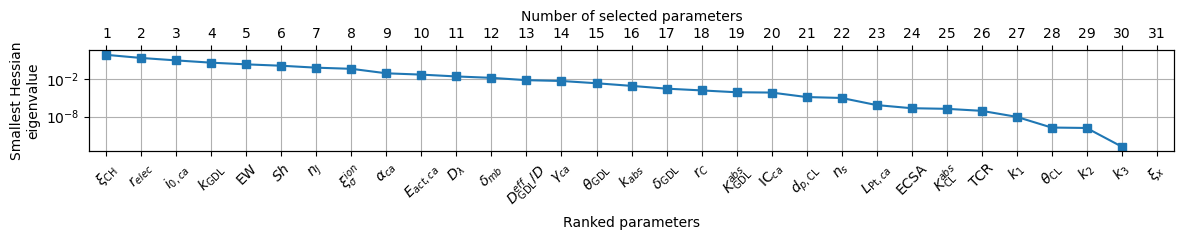

In [13]:
pe.load_global_sensitivity_results(f'sensitivity_results_{filename}.npz')
fig, ax, ax2 = pe.plot_parameter_ranking()


## Estimation results

In [ ]:
cv_results = load_cross_validation_results(
    filepath=f'results_{filename}.csv',
    base_model=pe,
)

IndexError: list index out of range

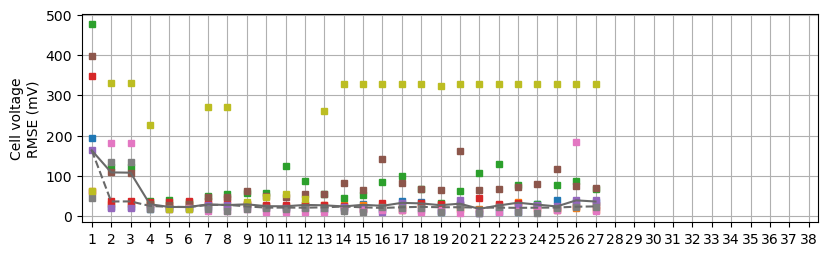

In [ ]:
fig, ax, voltage_rmse_df, optimal_n_voltage = plot_rmse_vs_complexity(
    cv_results,
    full_case_list,
    parameter_indices=P[:n_params],
    base_model=pe,
    model_builder=model_builder,
    simulate_callback=simulate_voltage,
    ylabel='Cell voltage\nRMSE (mV)',
    quantity_multiplier=1000,
    use_median=True,
    figsize=(9.5, 2.7),
    xrotation=70,
    dpi=300,
)
ax.semilogy()
legend = ax.get_legend()
legend.set_bbox_to_anchor((1, 1.6), transform=ax.transAxes)
ax.set_ylim([5,500])
fig.tight_layout()
fig.savefig(
    f'./figures/rmse_v_cell_vs_complexity_{filename}.png',
    dpi=300, bbox_inches='tight',
    bbox_extra_artists=[legend, fig.legends[0]],
)
print(f'Optimal number of parameters (voltage): {optimal_n_voltage}')

Optimal number of parameters (HFR): 19


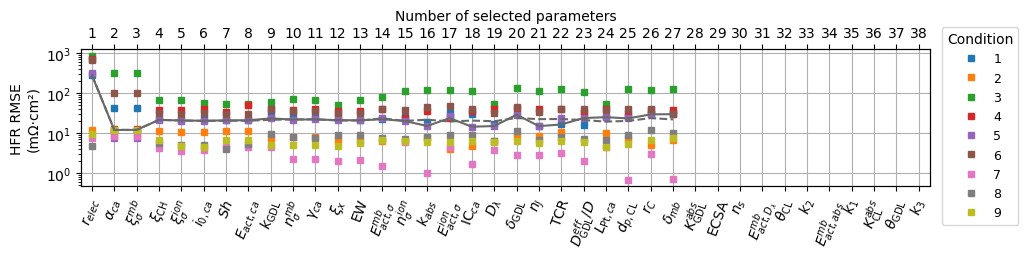

In [ ]:
fig, ax, hfr_rmse_df, optimal_n_hfr = plot_rmse_vs_complexity(
    cv_results,
    full_case_list,
    parameter_indices=P[:n_params],
    base_model=pe,
    model_builder=model_builder,
    simulate_callback=simulate_hfr,
    ylabel='HFR RMSE\n(mΩ·cm²)',
    use_median=True,
    quantity_multiplier=1000,
    figsize=(9.5, 2.7),
    xrotation=70,
    dpi=300,
)
ax.semilogy()
ax.get_legend().set_visible(False)
fig.tight_layout()
fig.savefig(f'./figures/rmse_hfr_vs_complexity_{filename}.png', dpi=300, bbox_inches='tight')
print(f'Optimal number of parameters (HFR): {optimal_n_hfr}')

In [ ]:
voltage_rmse_stats_df, voltage_rmse_latex = rmse_complexity_table(voltage_rmse_df)
print(voltage_rmse_latex)

hfr_rmse_stats_df, hfr_rmse_latex = rmse_complexity_table(hfr_rmse_df)
print(hfr_rmse_latex)

\begin{table}[h]
\caption{RMSE vs complexity}
\label{tab:rmse_complexity}
\begin{tabular}{lrrrrrrrrrrrrr}
\toprule
 & \multicolumn{9}{c}{Cases} \\
\cmidrule(lr){2-10}
 & 1.000000 & 2.000000 & 3.000000 & 4.000000 & 5.000000 & 6.000000 & 7.000000 & 8.000000 & 9.000000 & Min. & Max. & Median & Mean \\
n_parameters &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
1 & 193.0 & 61.5 & 477.7 & 347.7 & 163.0 & 397.5 & 59.1 & 45.4 & 61.3 & 45.4 & 477.7 & 163.0 & 200.7 \\
2 & 22.9 & 30.4 & 122.0 & 36.2 & 20.4 & 108.3 & 181.8 & 134.5 & 330.0 & 20.4 & 330.0 & 108.3 & 109.6 \\
3 & 22.9 & 30.4 & 122.0 & 36.2 & 20.4 & 107.6 & 181.8 & 134.5 & 329.7 & 20.4 & 329.7 & 107.6 & 109.5 \\
4 & 18.0 & 29.2 & 36.4 & 35.6 & 25.5 & 29.2 & 19.0 & 18.4 & 226.9 & 18.0 & 226.9 & 29.2 & 48.7 \\
5 & 19.6 & 28.3 & 39.0 & 34.1 & 22.4 & 26.4 & 18.1 & 16.4 & 17.5 & 16.4 & 39.0 & 22.4 & 24.6 \\
6 & 19.8 & 28.8 & 35.7 & 37.0 & 22.2 & 29.2 & 18.7 & 16.4 & 18.6 & 16.4 & 37.0 & 22.2 & 25.1 \\
7 & 21.4 & 28.9 & 50.8 & 38.1 & 27

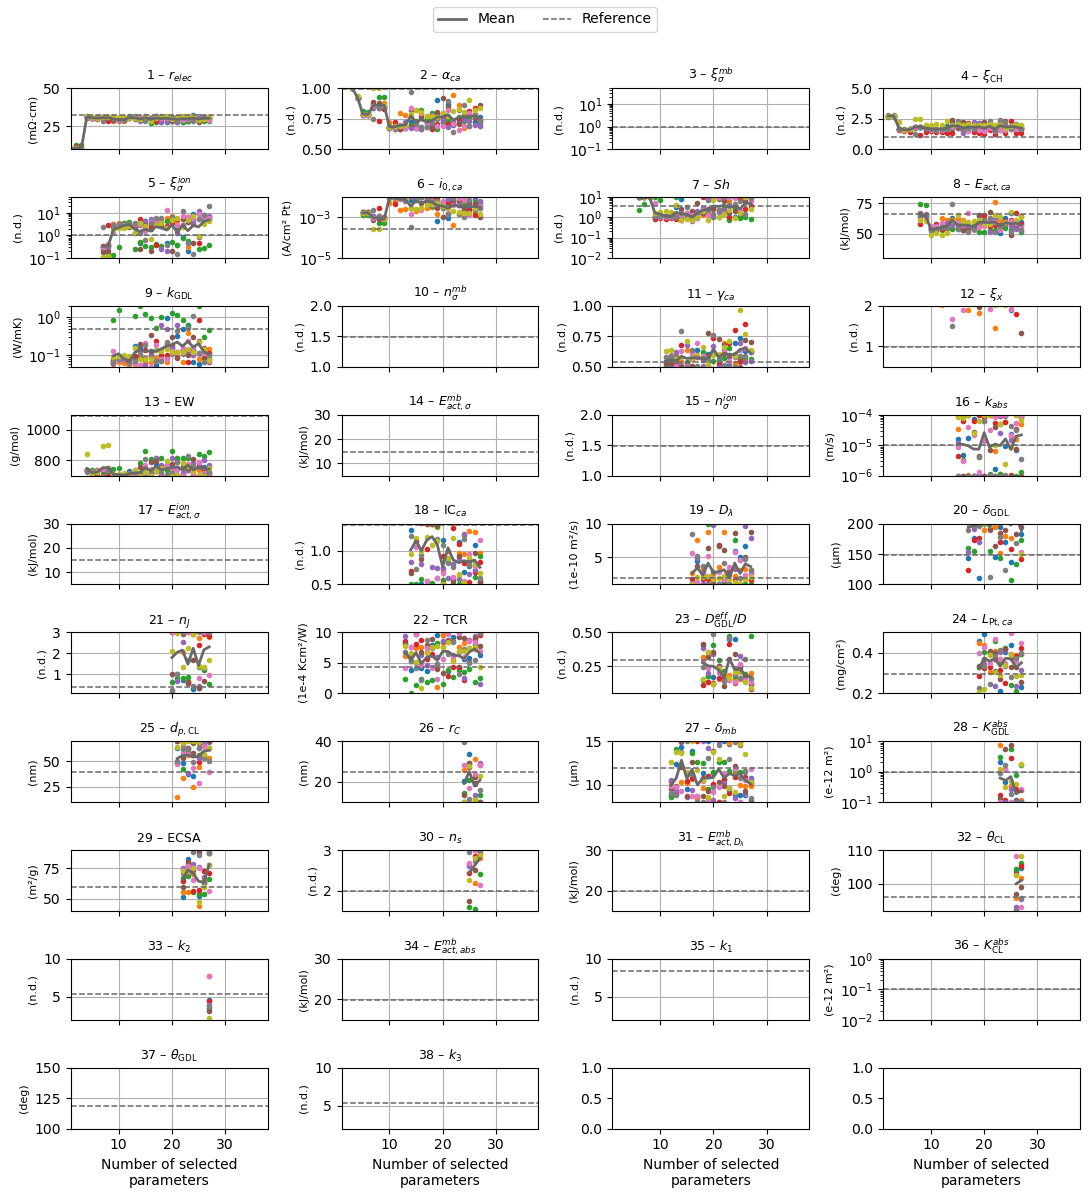

In [ ]:
fig, axes, mean_vals, lower_ci, upper_ci = plot_parameter_vs_complexity(
    cv_results,
    P[:n_params],
    pe,
    parameter_units,
    condition_color,
    initial_parameters,
    plot_ci=False,
    n_cols=4,
    figsize=(11, 12),
    save_path=f'./figures/parameter_evolution_{filename}.png',
    dpi=300,
)

Cell voltage RMSE & 0.03 & 0.03 & 0.07 & 0.03 & 0.01 & 0.07 & 0.01 & 0.02 & 0.33 \\
Cell voltage max. error & 0.06 & 0.05 & 0.08 & 0.05 & 0.02 & 0.13 & 0.02 & 0.03 & 0.63 \\


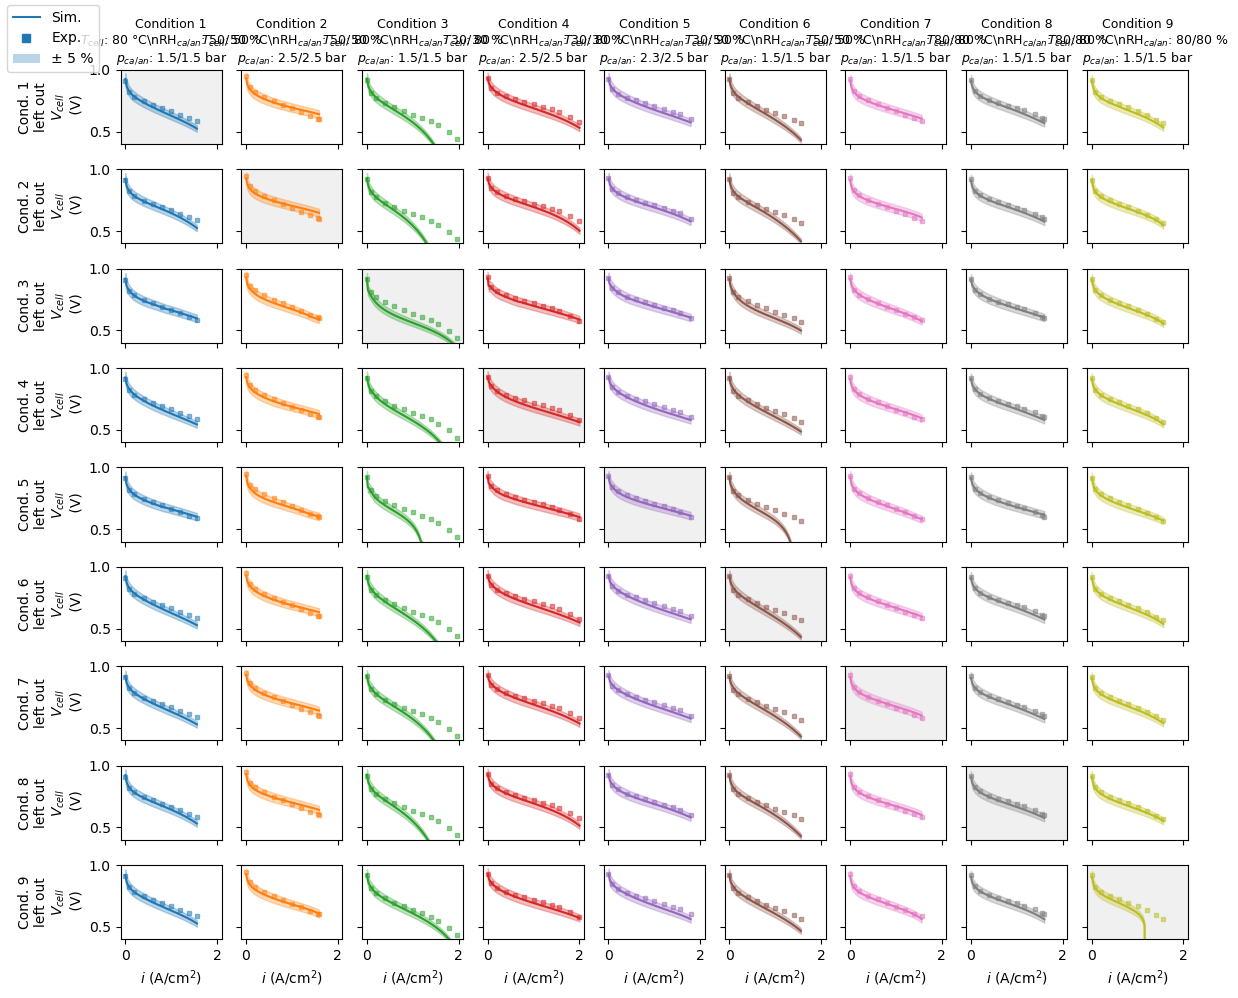

In [ ]:
n_selected = 18  # adjust as needed

case_titles = {
    case: (
        f'Condition {k+1}\n'
        + rf'$T_{{cell}}$: {conditions_df.loc[case_variations.loc[case, "Variation"], "temperature"]:.0f} °C\n'
        + rf'RH$_{{ca/an}}$: '
        + f'{conditions_df.loc[case_variations.loc[case, "Variation"], "rh-ca"]:.0f}/'
        + f'{conditions_df.loc[case_variations.loc[case, "Variation"], "rh-an"]:.0f} %\n'
        + rf'$p_{{ca/an}}$: '
        + f'{conditions_df.loc[case_variations.loc[case, "Variation"], "pressure-ca"]:.1f}/'
        + f'{conditions_df.loc[case_variations.loc[case, "Variation"], "pressure-an"]:.1f} bar'
    )
    for k, case in enumerate(full_case_list)
}

fig, ax, rmse, maxerr, rmse_str, maxerr_str = plot_cross_validation_curves(
    n_parameters=n_selected,
    cv_results=cv_results,
    case_list=full_case_list,
    case_table=case_titles,
    condition_color=condition_color,
    simulate_callback=simulate_voltage_full,
    model_builder=model_builder,
    quantity_name='Cell voltage',
    quantity_symbol='$V_{cell}$\n',
    quantity_unit='V',
    uncertainty=0.05,
    save_path=f'figures/cross-validation-voltage_{filename}.png',
)
ax[0, 0].set_ylim([0.4, 1])
for k in range(len(ax[0, ...])):
    ax[0, k].set_title(list(case_titles.values())[k], fontsize=9)
fig.legends[0].set_bbox_to_anchor((0, 1.0))
fig.legends[0].set_ncols(2)
fig.tight_layout()
fig.savefig(f'./figures/cross-validation-voltage_{filename}.png', dpi=300,
            bbox_inches='tight', bbox_extra_artists=[fig.legends[0]])
print(rmse_str)
print(maxerr_str)

HFR RMSE & nan & nan & nan & nan & nan & nan & nan & nan & nan \\
HFR max. error & nan & nan & nan & nan & nan & nan & nan & nan & nan \\


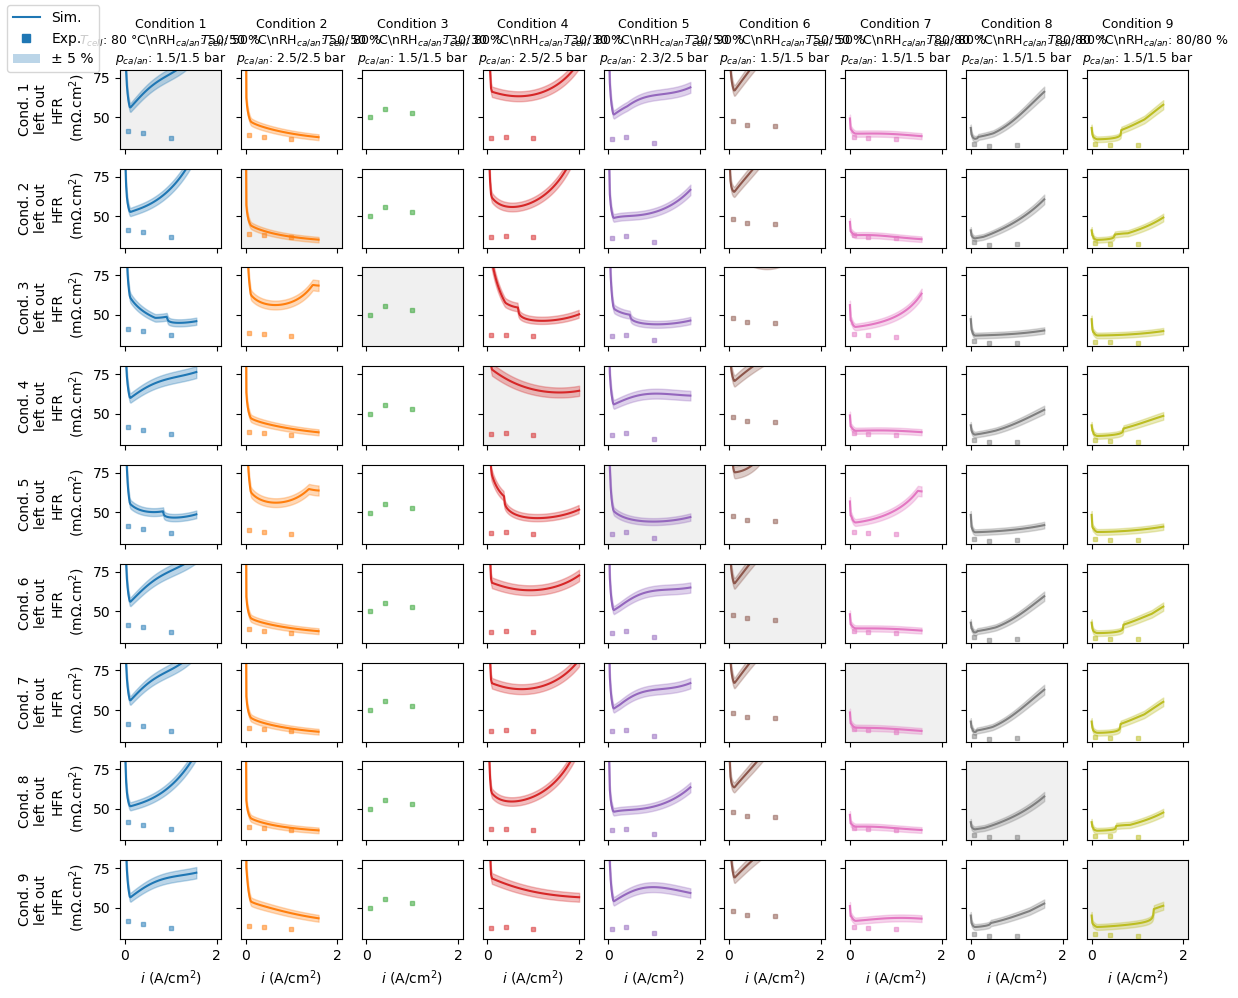

In [ ]:
fig, ax, rmse, maxerr, rmse_str, maxerr_str = plot_cross_validation_curves(
    n_parameters=n_selected,
    cv_results=cv_results,
    case_list=full_case_list,
    case_table=case_titles,
    condition_color=condition_color,
    simulate_callback=simulate_hfr_full,
    model_builder=model_builder,
    quantity_name='HFR',
    quantity_symbol='HFR\n',
    quantity_unit='m$\Omega$.cm$^2$',
    uncertainty=0.05,
    save_path=f'figures/cross-validation-hfr_{filename}.png',
)
ax[0, 0].set_ylim([30, 80])
for k in range(len(ax[0, ...])):
    ax[0, k].set_title(list(case_titles.values())[k], fontsize=9)
fig.legends[0].set_bbox_to_anchor((0, 1.0))
fig.legends[0].set_ncols(2)
fig.tight_layout()
fig.savefig(f'./figures/cross-validation-hfr_{filename}.png', dpi=300, bbox_inches='tight')
print(rmse_str)
print(maxerr_str)

/var/folders/q2/mryrbb1x7yz_7_1dzt__d5n8w_l3v1/T/ipykernel_94525/2612541677.py:31: UserWarning: Mismatched number of handles and labels: len(handles) = 3 len(labels) = 4
  leg2 = fig.legend(handles=handles + [l2], labels=labels + ['Exp.'],


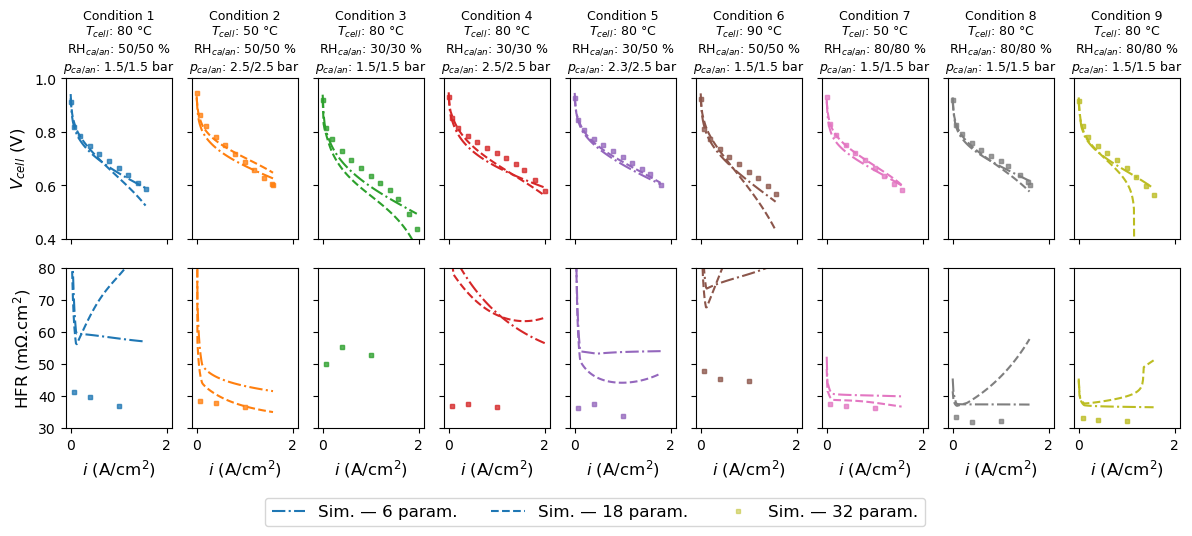

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5), nrows=2, ncols=len(full_case_list), sharex=True, sharey='row')
fig.set_tight_layout(True)
dash = ['-.', '--', '-']
handles = []

for i, n in enumerate([6, 18, 32]):
    try:
        folds = get_folds_for_complexity(cv_results, n)
    except Exception:
        continue
    for k, fold in enumerate(folds):
        p    = fold['test_case']
        cell = create_cell(fold['model_parameters'])
        i_sim, U_sim, i_exp, U_exp = simulate_voltage_full(p, cell)

        ax[0, k].set_title(titles[p], fontsize=9)
        l1, = ax[0, k].plot(i_sim, U_sim, dash[i] + condition_color[p])
        l2, = ax[0, k].plot(i_exp, U_exp, 's' + condition_color[p],
                             markersize=2.5, alpha=0.5)

        i_sim_h, hfr_sim, _, _ = simulate_hfr_full(p, cell)
        ax[1, k].plot(i_sim_h, hfr_sim, dash[i] + condition_color[p])
        ax[1, k].plot(i_exp[np.isfinite(exp_hfr[p])],
                      exp_hfr[p][np.isfinite(exp_hfr[p])] * 1e3,
                      's' + condition_color[p], markersize=2.5, alpha=0.5)
        ax[1, k].set_xlabel('$i$ (A/cm$^2$)', fontsize=12)
        if k == 0:
            handles.append(l1)

labels = [f'Sim. — {n} param.' for n in [6, 18, 32]]
leg2 = fig.legend(handles=handles + [l2], labels=labels + ['Exp.'],
                  loc='lower center', bbox_to_anchor=(0.5, -.08), ncols=4, fontsize=12)
ax[0, 0].set_ylabel('$V_{cell}$ (V)', fontsize=12)
ax[1, 0].set_ylabel('HFR (m$\Omega$.cm$^2$)', fontsize=12)
ax[0, 0].set_ylim([0.4, 1])
ax[1, 0].set_ylim([30, 80])
fig.tight_layout()
plt.savefig(f'figures/cross-validation-UI-curves-multiple-params-{filename}.png',
            dpi=300, bbox_inches='tight')

## Internal variables

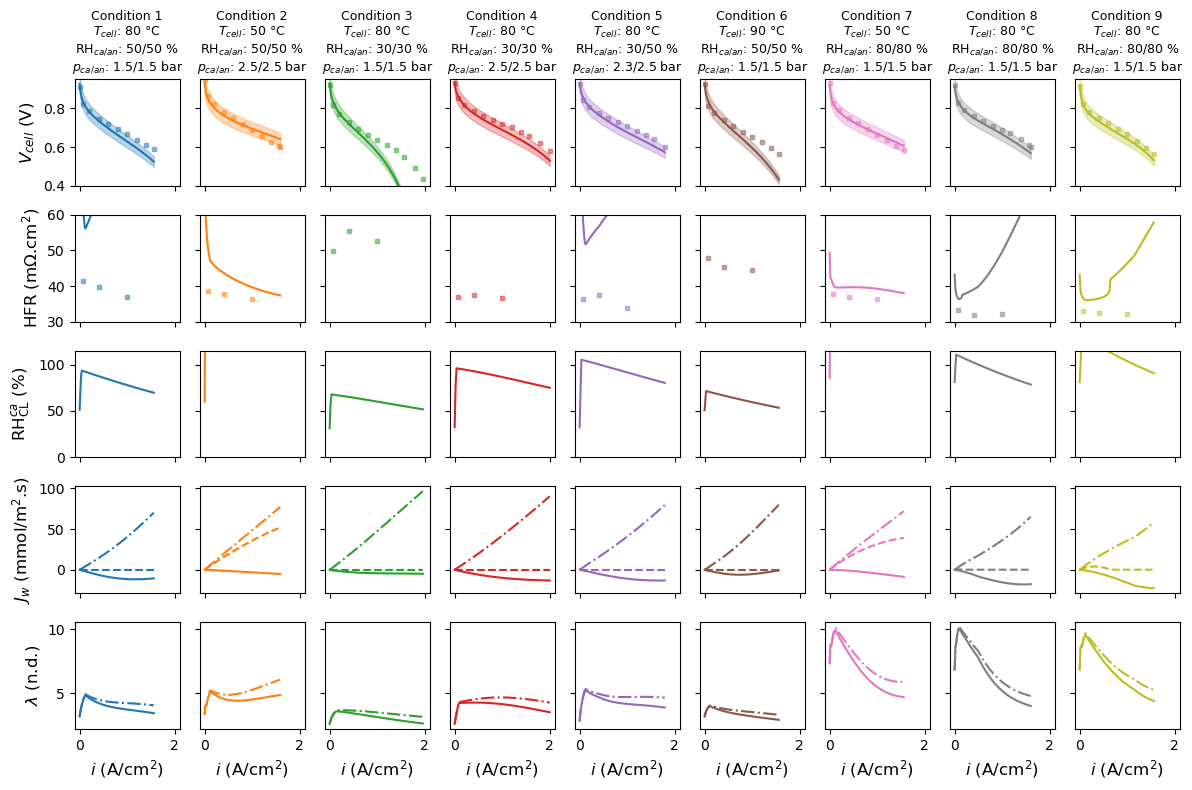

In [ ]:
testing_condition = 1
selected_parameters = n_selected

fig, ax = plt.subplots(figsize=(12, 8), nrows=5, ncols=len(full_case_list),
                       sharex=True, sharey='row')
fig.set_tight_layout(True)

folds = get_folds_for_complexity(cv_results, selected_parameters)
fold  = folds[testing_condition - 1]

for k, p in enumerate(full_case_list):
    cell  = create_cell(fold['model_parameters'])
    cond  = cases_dense[p]['conditions']
    state = solve_case(cell, cond)
    hfr   = _esm.voltage_model.high_frequency_resistance(cell, state) * 1e7  # mΩ·cm²

    i_sim = np.atleast_1d(cond.current_density) * 1e-4
    U_sim = state.cell_voltage

    ax[0, k].set_title(titles[p], fontsize=9)

    l0, = ax[0, k].plot(i_sim, U_sim, condition_color[p], label='Sim.')
    ax[0, k].fill_between(i_sim, 0.95 * U_sim, 1.05 * U_sim,
                          color=condition_color[p], alpha=0.3, label='± 5 %')
    ax[0, k].plot(exp_current[p], exp_voltage[p], 's' + condition_color[p],
                  markersize=2.5, alpha=0.5, label='Exp.')
    ax[0, k].set_ylim([0.4, 0.95])

    ax[1, k].plot(i_sim, hfr, condition_color[p])
    hfr_mask = np.isfinite(exp_hfr[p])
    ax[1, k].plot(exp_current[p][hfr_mask], exp_hfr[p][hfr_mask] * 1e3,
                  's' + condition_color[p], markersize=2.5, alpha=0.5)
    ax[1, k].set_ylim([30, 60])

    ax[2, k].plot(i_sim, 100 * state.ca.rh_at_cl_without_crossover,
                  '-' + condition_color[p], label=r'RH$_{\text{CL}}$')
    ax[2, k].set_ylim([0, 115])

    ax[3, k].plot(i_sim, 1e6 * state.ca.membrane_water_flux,
                  '-' + condition_color[p], label='$J_{mb}^{ca}$')
    ax[3, k].plot(i_sim, 1e6 * state.ca.liquid_flux,
                  '--' + condition_color[p], label='$J_l^{ca}$')
    ax[3, k].plot(i_sim, 1e6 * state.ca.water_flux,
                  '-.' + condition_color[p], label='$J_w^{ca}$')

    ax[4, k].plot(i_sim, state.ca.cl.ionomer_water_content,
                  '-.' + condition_color[p], label=r'$\lambda^{ca}_{ion,\text{CL}}$')
    ax[4, k].plot(i_sim, state.membrane.water_content,
                  '-' + condition_color[p], label=r'$\lambda^{avg}_{mb}$')

    ax[-1, k].set_xlabel('$i$ (A/cm$^2$)', fontsize=12)

ax[0, 0].set_ylabel('$V_{cell}$ (V)', fontsize=12)
ax[1, 0].set_ylabel('HFR (m$\Omega$.cm$^2$)', fontsize=12)
ax[2, 0].set_ylabel('RH$_{\mathrm{CL}}^{ca}$ (%)', fontsize=12)
ax[3, 0].set_ylabel('$J_w$ (mmol/m$^2$.s)', fontsize=12)
ax[4, 0].set_ylabel('$\lambda$ (n.d.)', fontsize=12)

fig.tight_layout()
plt.savefig(f'figures/internal-variables-{filename}.png', dpi=300, bbox_inches='tight')

## Computational time

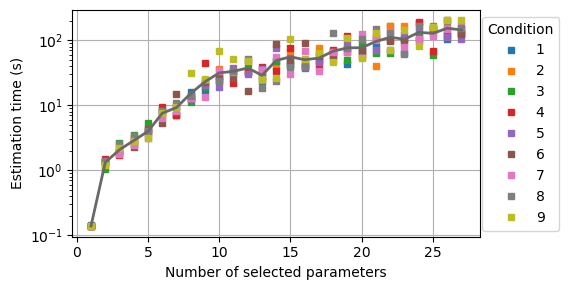

In [ ]:
complexity_levels = get_complexity_levels(cv_results)

fig, ax = plt.subplots(figsize=(5, 3))
t_avg = np.zeros(len(complexity_levels))
handles = []
for k, case in enumerate(full_case_list):
    t_est = np.array([
        get_folds_for_complexity(cv_results, n)[k]['elapsed_time']
        for n in complexity_levels
    ])
    t_avg += t_est / len(full_case_list)
    l, = ax.semilogy(complexity_levels, t_est, 's', color=condition_color[case],
                     alpha=1, markersize=5)
    handles.append(l)

ax.plot(complexity_levels, t_avg, 'dimgray', linewidth=2)
ax.set_xlabel('Number of selected parameters')
ax.set_ylabel('Estimation time (s)')
ax.grid()
fig.legend(handles=handles, labels=[str(c) for c in full_case_list],
           loc='upper left', bbox_to_anchor=(0.96, 0.95), title='Condition')
fig.tight_layout()
plt.savefig(f'figures/computation_time_{filename}.png', dpi=300, bbox_inches='tight')
plt.show()